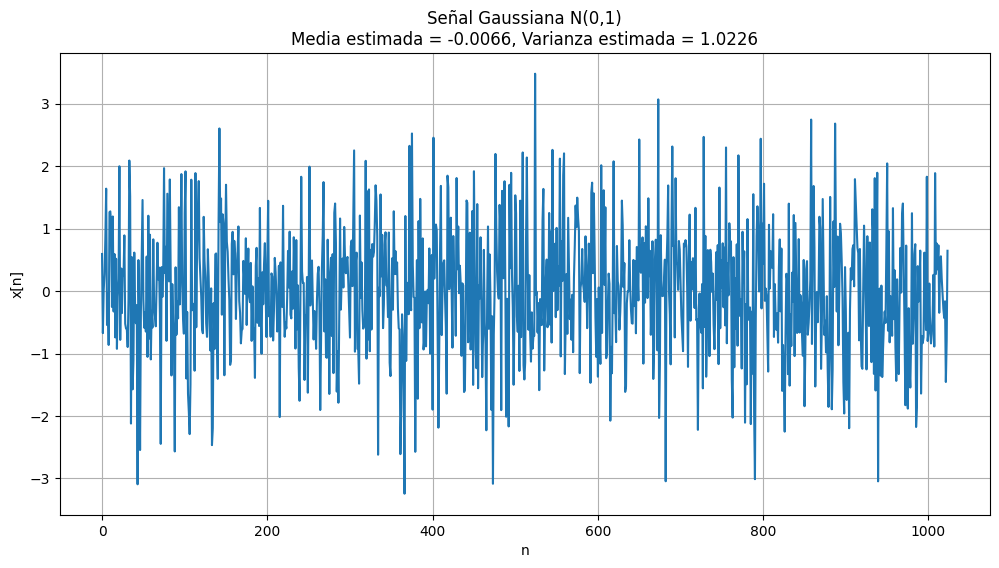

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
N = 1024
mu = 0.0
sigma = 1.0

# Generación de señal gaussiana N(0,1)
x = torch.normal(mean=mu, std=sigma, size=(N,))

# Cálculo empírico de media y varianza
mean_emp = torch.mean(x)
var_emp = torch.var(x, unbiased=False)  # estimador 1/N

# Gráfica
plt.figure(figsize=(12,6))
plt.plot(x.numpy())
plt.title(f'Señal Gaussiana N(0,1)\nMedia estimada = {mean_emp:.4f}, Varianza estimada = {var_emp:.4f}')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)
plt.show()


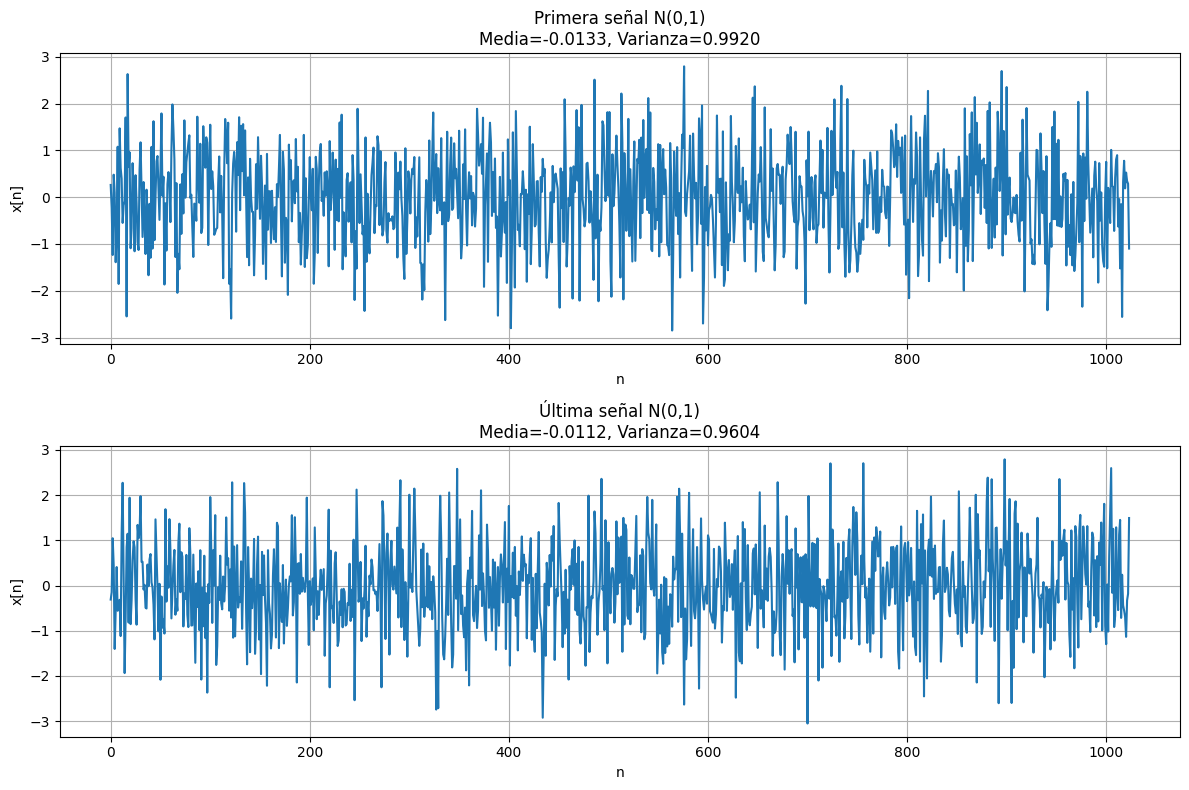

In [ ]:
import torch
import matplotlib.pyplot as plt

# Parámetros
N = 1024
L = 64
mu = 0.0
sigma = 1.0

# Generación de 64 realizaciones gaussianas N(0,1)
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# Primera y última señal
x_first = signals[0]
x_last = signals[-1]

# Cálculo empírico primera señal
mean_first = torch.mean(x_first)
var_first = torch.var(x_first, unbiased=False)

# Cálculo empírico última señal
mean_last = torch.mean(x_last)
var_last = torch.var(x_last, unbiased=False)

# Gráfica
plt.figure(figsize=(12,8))

# Fila superior: primera señal
plt.subplot(2,1,1)
plt.plot(x_first.numpy())
plt.title(f'Primera señal N(0,1)\nMedia={mean_first:.4f}, Varianza={var_first:.4f}')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)

# Fila inferior: última señal
plt.subplot(2,1,2)
plt.plot(x_last.numpy())
plt.title(f'Última señal N(0,1)\nMedia={mean_last:.4f}, Varianza={var_last:.4f}')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)

plt.tight_layout()
plt.show()


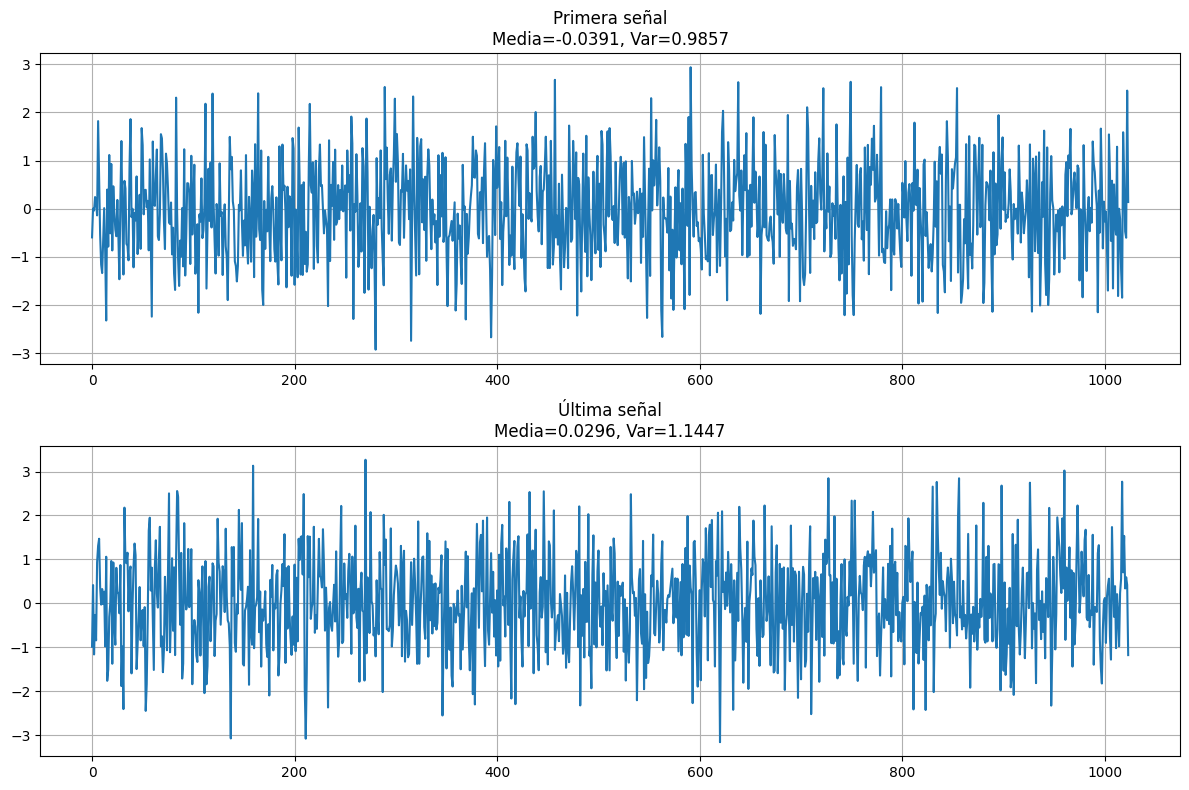

Instantes seleccionados: 345 y 576
En n1:
Media = 0.054712165147066116
Varianza = 0.59706711769104
En n2:
Media = -0.06491959095001221
Varianza = 0.6339244842529297


In [ ]:
import torch
import matplotlib.pyplot as plt
import random

# Parámetros
N = 1024
L = 64
mu = 0.0
sigma = 1.0

# Generación de 64 realizaciones gaussianas
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# Primera y última señal
x_first = signals[0]
x_last = signals[-1]

# Estadísticos temporales
mean_first = torch.mean(x_first)
var_first = torch.var(x_first, unbiased=False)

mean_last = torch.mean(x_last)
var_last = torch.var(x_last, unbiased=False)

# Selección aleatoria de dos instantes
n1, n2 = random.sample(range(N), 2)

# Estadísticos sobre el ensemble en esos instantes
mean_n1 = torch.mean(signals[:, n1])
var_n1 = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2 = torch.var(signals[:, n2], unbiased=False)

# Gráfica
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(x_first.numpy())
plt.title(f'Primera señal\nMedia={mean_first:.4f}, Var={var_first:.4f}')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(x_last.numpy())
plt.title(f'Última señal\nMedia={mean_last:.4f}, Var={var_last:.4f}')
plt.grid(True)

plt.tight_layout()
plt.show()

# Mostrar resultados ensemble
print("Instantes seleccionados:", n1, "y", n2)
print("En n1:")
print("Media =", mean_n1.item())
print("Varianza =", var_n1.item())

print("En n2:")
print("Media =", mean_n2.item())
print("Varianza =", var_n2.item())


INSTANTE     | MEDIA      | VARIANZA  
----------------------------------------
n1 (977 )    |  -0.1970   |   1.3418  
n2 ( 45 )    |   0.2103   |   1.3699  


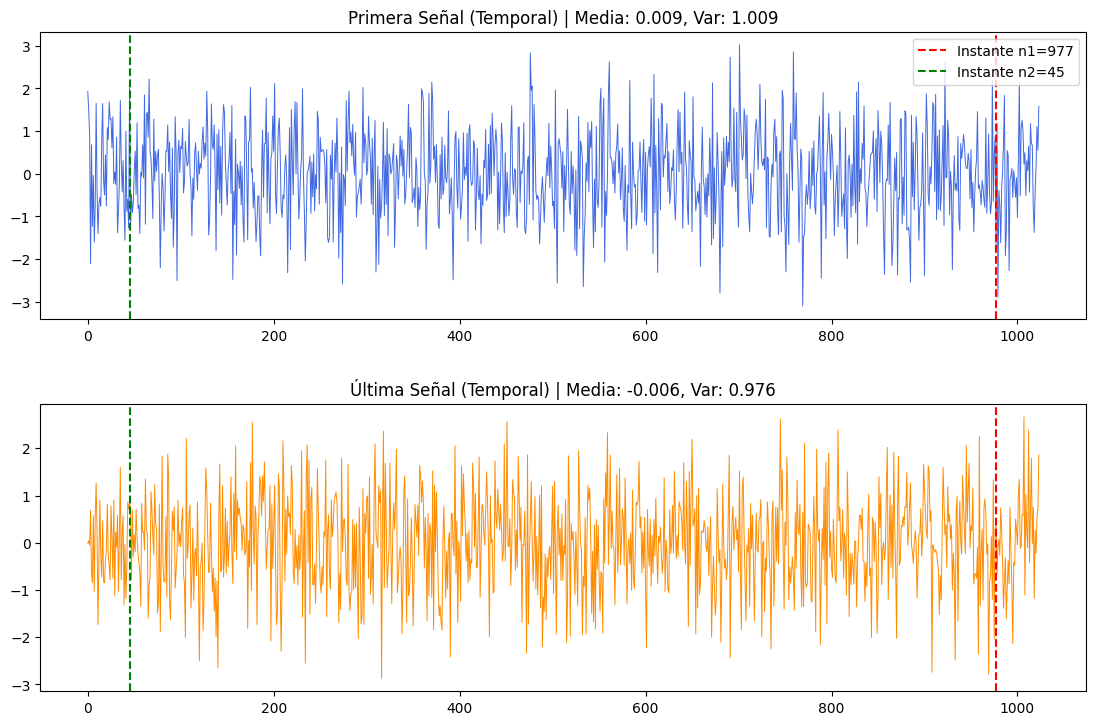

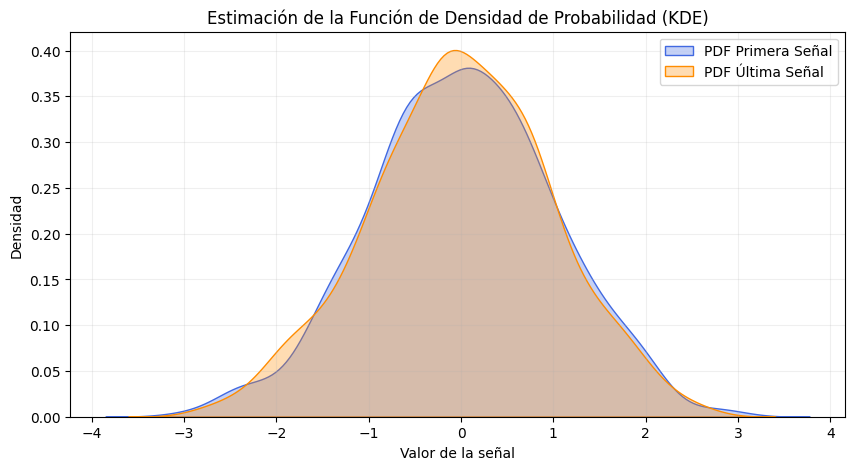

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==============================
# 1. Configuración de parámetros
# ==============================
N = 1024      # puntos por señal
L = 8        # realizaciones
mu = 0.0
sigma = 1.0

torch.manual_seed(42)

# ==============================
# 2. Generación del proceso
# ==============================
# Proceso estocástico X(i,n) ~ N(0,1)
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# ==============================
# 3. Selección de instantes aleatorios
# ==============================
n1, n2 = random.sample(range(N), 2)

# Estadística transversal (ensemble)
mean_n1 = torch.mean(signals[:, n1])
var_n1  = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2  = torch.var(signals[:, n2], unbiased=False)

# ==============================
# 4. Visualización temporal
# ==============================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.tight_layout(pad=4.0)

# Primera señal
x_first = signals[0]
m_first = torch.mean(x_first)
v_first = torch.var(x_first, unbiased=False)

ax1.plot(x_first.numpy(), color='royalblue', lw=0.7)
ax1.set_title(f"Primera Señal (Temporal) | Media: {m_first:.3f}, Var: {v_first:.3f}")
ax1.axvline(n1, color='red', linestyle='--', label=f'Instante n1={n1}')
ax1.axvline(n2, color='green', linestyle='--', label=f'Instante n2={n2}')
ax1.legend(loc='upper right')

# Última señal
x_last = signals[-1]
m_last = torch.mean(x_last)
v_last = torch.var(x_last, unbiased=False)

ax2.plot(x_last.numpy(), color='darkorange', lw=0.7)
ax2.set_title(f"Última Señal (Temporal) | Media: {m_last:.3f}, Var: {v_last:.3f}")
ax2.axvline(n1, color='red', linestyle='--')
ax2.axvline(n2, color='green', linestyle='--')

# ==============================
# 5. Visualización PDF (KDE)
# ==============================
plt.figure(figsize=(10, 5))

sns.kdeplot(x_first.numpy(), bw_adjust=1, label="PDF Primera Señal",
            color='royalblue', fill=True, alpha=0.3)

sns.kdeplot(x_last.numpy(), bw_adjust=1, label="PDF Última Señal",
            color='darkorange', fill=True, alpha=0.3)

plt.title("Estimación de la Función de Densidad de Probabilidad (KDE)")
plt.xlabel("Valor de la señal")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)

# ==============================
# 6. Salida numérica formateada
# ==============================
print(f"{'INSTANTE':<12} | {'MEDIA':<10} | {'VARIANZA':<10}")
print("-" * 40)
print(f"n1 ({n1:^4})    | {mean_n1.item():^10.4f} | {var_n1.item():^10.4f}")
print(f"n2 ({n2:^4})    | {mean_n2.item():^10.4f} | {var_n2.item():^10.4f}")

plt.show()


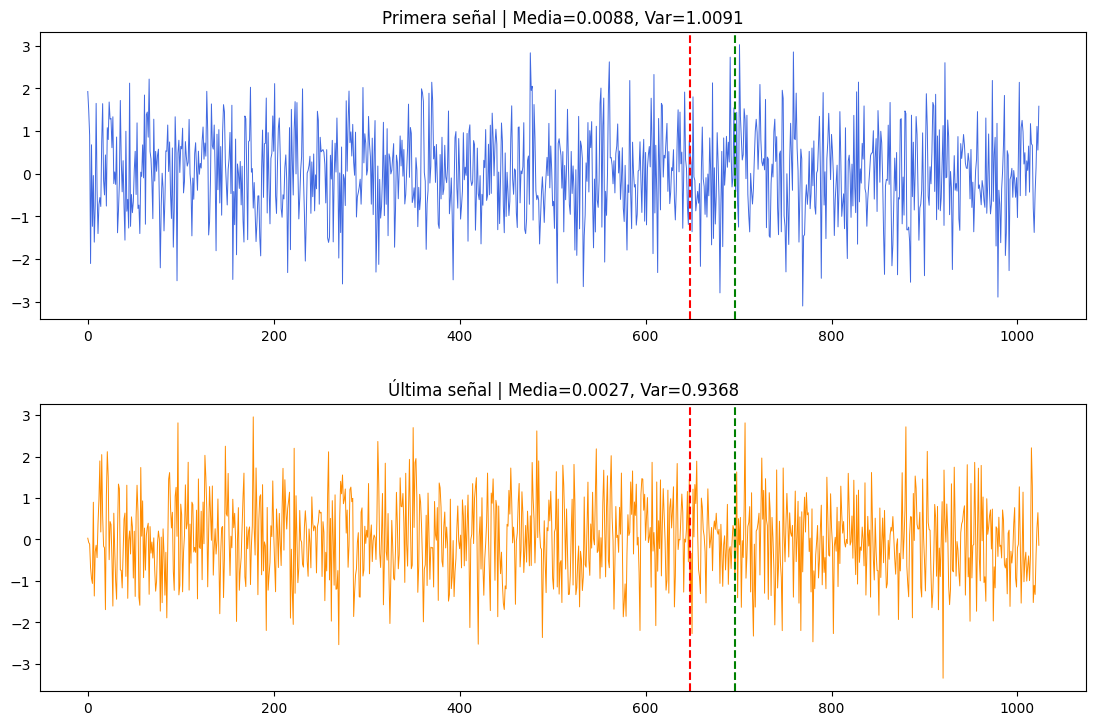

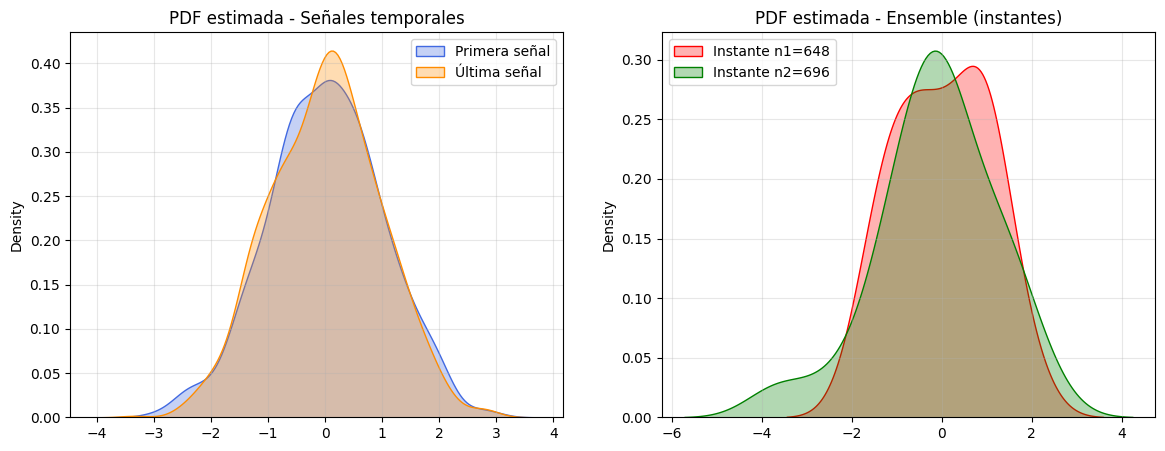


--- Estadísticos Ensemble ---
Instante n1 = 648
Media = 0.021737
Varianza = 1.035116

Instante n2 = 696
Media = -0.131636
Varianza = 1.629810


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==================================
# Parámetros
# ==================================
N = 1024
L = 23
mu = 0.0
sigma = 1.0

torch.manual_seed(42)

# ==================================
# Generación del proceso
# ==================================
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# ==================================
# Primera y última señal
# ==================================
x_first = signals[0]
x_last  = signals[-1]

mean_first = torch.mean(x_first)
var_first  = torch.var(x_first, unbiased=False)

mean_last  = torch.mean(x_last)
var_last   = torch.var(x_last, unbiased=False)

# ==================================
# Selección de dos instantes
# ==================================
n1, n2 = random.sample(range(N), 2)

mean_n1 = torch.mean(signals[:, n1])
var_n1  = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2  = torch.var(signals[:, n2], unbiased=False)

# ==================================
# FIGURA 1: Señales temporales
# ==================================
fig1, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
fig1.tight_layout(pad=4)

ax1.plot(x_first.numpy(), color='royalblue', lw=0.7)
ax1.set_title(f"Primera señal | Media={mean_first:.4f}, Var={var_first:.4f}")
ax1.axvline(n1, color='red', linestyle='--')
ax1.axvline(n2, color='green', linestyle='--')

ax2.plot(x_last.numpy(), color='darkorange', lw=0.7)
ax2.set_title(f"Última señal | Media={mean_last:.4f}, Var={var_last:.4f}")
ax2.axvline(n1, color='red', linestyle='--')
ax2.axvline(n2, color='green', linestyle='--')

# ==================================
# FIGURA 2: PDFs estimadas
# ==================================
fig2, axes = plt.subplots(1,2, figsize=(14,5))

# PDF primera y última señal
sns.kdeplot(x_first.numpy(), ax=axes[0],
            color='royalblue', label='Primera señal',
            fill=True, alpha=0.3)

sns.kdeplot(x_last.numpy(), ax=axes[0],
            color='darkorange', label='Última señal',
            fill=True, alpha=0.3)

axes[0].set_title("PDF estimada - Señales temporales")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PDF ensemble en instantes n1 y n2
sns.kdeplot(signals[:, n1].numpy(), ax=axes[1],
            color='red', label=f'Instante n1={n1}',
            fill=True, alpha=0.3)

sns.kdeplot(signals[:, n2].numpy(), ax=axes[1],
            color='green', label=f'Instante n2={n2}',
            fill=True, alpha=0.3)

axes[1].set_title("PDF estimada - Ensemble (instantes)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

# ==================================
# Resultados numéricos
# ==================================
print("\n--- Estadísticos Ensemble ---")
print(f"Instante n1 = {n1}")
print(f"Media = {mean_n1:.6f}")
print(f"Varianza = {var_n1:.6f}")

print(f"\nInstante n2 = {n2}")
print(f"Media = {mean_n2:.6f}")
print(f"Varianza = {var_n2:.6f}")



========== ESTADÍSTICA TEMPORAL ==========
Primera señal -> Media = 0.008771 | Varianza = 1.009132
Última señal  -> Media = 0.009402  | Varianza = 1.065022

========== ESTADÍSTICA TRANSVERSAL (ENSEMBLE) ==========
Instante n1 = 93 -> Media = 0.123451 | Varianza = 1.025314
Instante n2 = 411 -> Media = -0.005581 | Varianza = 0.858408


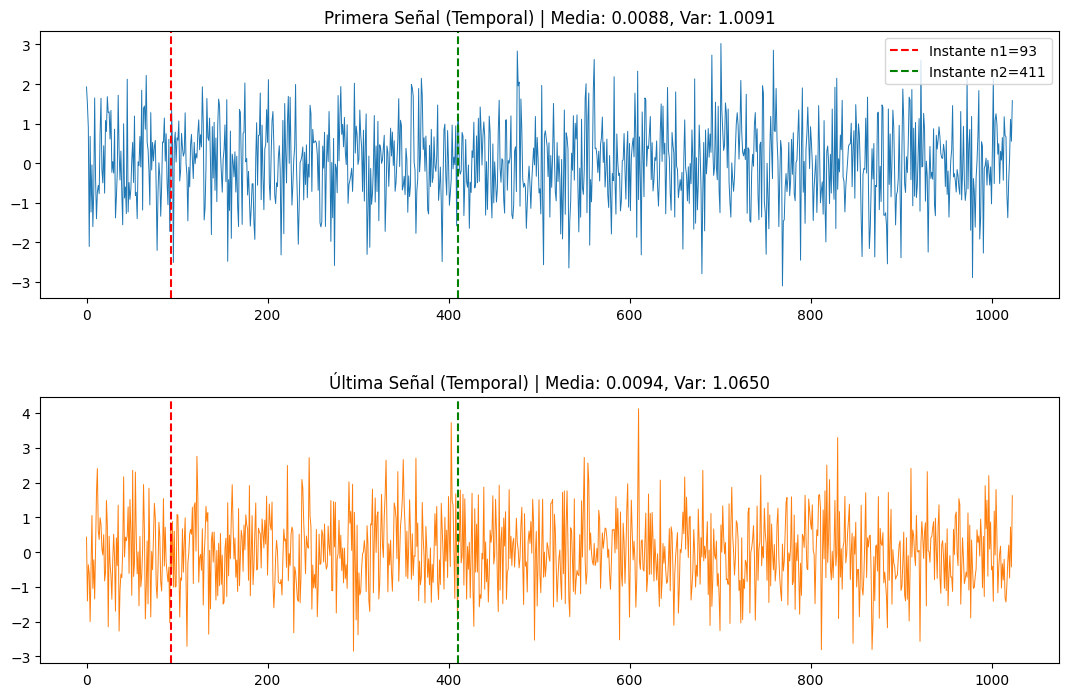

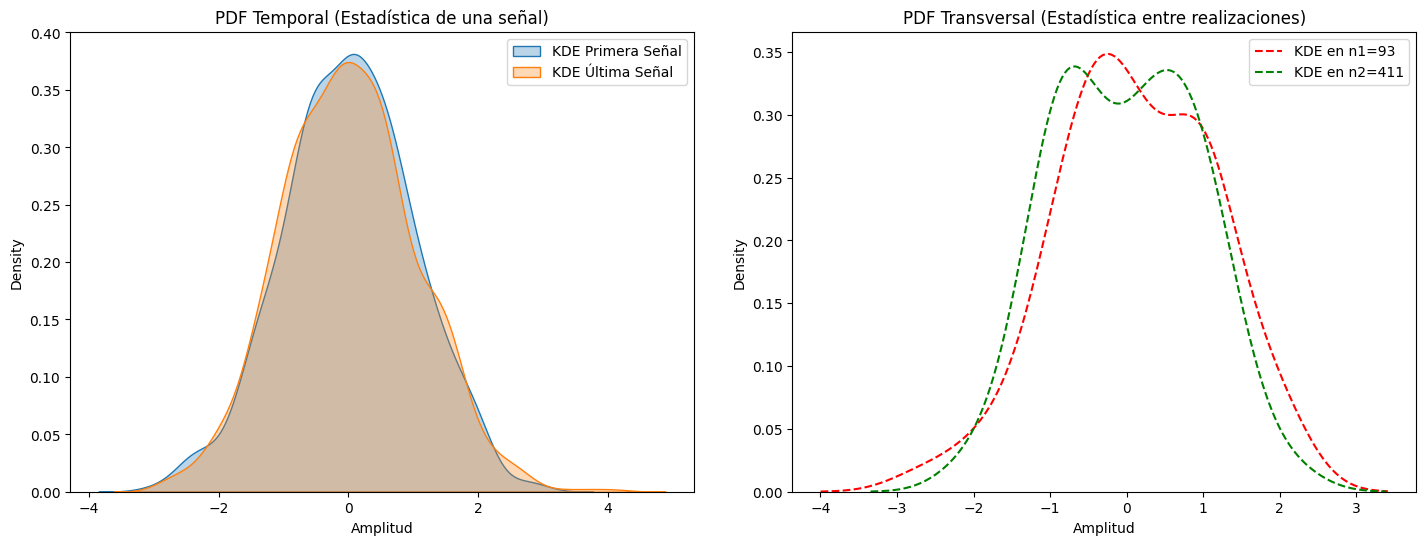

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==============================
# 1. Parámetros del proceso
# ==============================
N = 1024    # puntos por señal
L = 64      # número de realizaciones
mu = 0.0
sigma = 1.0

torch.manual_seed(42)

# ==============================
# 2. Generación del proceso estocástico
# ==============================
# X(i,n) ~ N(0,1)
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# ==============================
# 3. Selección de instantes aleatorios (ensemble)
# ==============================
n1, n2 = random.sample(range(N), 2)

# Estadística transversal (ensemble)
mean_n1 = torch.mean(signals[:, n1])
var_n1  = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2  = torch.var(signals[:, n2], unbiased=False)

# ==============================
# 4. Estadística temporal
# ==============================
x_first = signals[0]
x_last  = signals[-1]

mean_first = torch.mean(x_first)
var_first  = torch.var(x_first, unbiased=False)

mean_last  = torch.mean(x_last)
var_last   = torch.var(x_last, unbiased=False)

# ==============================
# --- FIGURA 1: SEÑALES TEMPORALES ---
# ==============================
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig1.tight_layout(pad=5.0)

# Primera señal
ax1.plot(x_first.numpy(), color='tab:blue', lw=0.7)
ax1.set_title(f"Primera Señal (Temporal) | Media: {mean_first:.4f}, Var: {var_first:.4f}")
ax1.axvline(n1, color='red', linestyle='--', label=f'Instante n1={n1}')
ax1.axvline(n2, color='green', linestyle='--', label=f'Instante n2={n2}')
ax1.legend(loc='upper right')

# Última señal
ax2.plot(x_last.numpy(), color='tab:orange', lw=0.7)
ax2.set_title(f"Última Señal (Temporal) | Media: {mean_last:.4f}, Var: {var_last:.4f}")
ax2.axvline(n1, color='red', linestyle='--')
ax2.axvline(n2, color='green', linestyle='--')

# ==============================
# --- FIGURA 2: PDFs COMPARATIVAS ---
# ==============================
fig2, (ax_pdf_temp, ax_pdf_trans) = plt.subplots(1, 2, figsize=(15, 6))
fig2.tight_layout(pad=4.0)

# PDF temporal (primera vs última señal)
sns.kdeplot(x_first.numpy(), ax=ax_pdf_temp,
            label="KDE Primera Señal",
            color='tab:blue', fill=True, alpha=0.3)

sns.kdeplot(x_last.numpy(), ax=ax_pdf_temp,
            label="KDE Última Señal",
            color='tab:orange', fill=True, alpha=0.3)

ax_pdf_temp.set_title("PDF Temporal (Estadística de una señal)")
ax_pdf_temp.set_xlabel("Amplitud")
ax_pdf_temp.legend()

# PDF transversal (ensemble en n1 y n2)
sns.kdeplot(signals[:, n1].numpy(), ax=ax_pdf_trans,
            label=f"KDE en n1={n1}", color='red', ls='--')

sns.kdeplot(signals[:, n2].numpy(), ax=ax_pdf_trans,
            label=f"KDE en n2={n2}", color='green', ls='--')

ax_pdf_trans.set_title("PDF Transversal (Estadística entre realizaciones)")
ax_pdf_trans.set_xlabel("Amplitud")
ax_pdf_trans.legend()

# ==============================
# 5. Resultados numéricos
# ==============================
print("\n========== ESTADÍSTICA TEMPORAL ==========")
print(f"Primera señal -> Media = {mean_first:.6f} | Varianza = {var_first:.6f}")
print(f"Última señal  -> Media = {mean_last:.6f}  | Varianza = {var_last:.6f}")

print("\n========== ESTADÍSTICA TRANSVERSAL (ENSEMBLE) ==========")
print(f"Instante n1 = {n1} -> Media = {mean_n1:.6f} | Varianza = {var_n1:.6f}")
print(f"Instante n2 = {n2} -> Media = {mean_n2:.6f} | Varianza = {var_n2:.6f}")

plt.show()


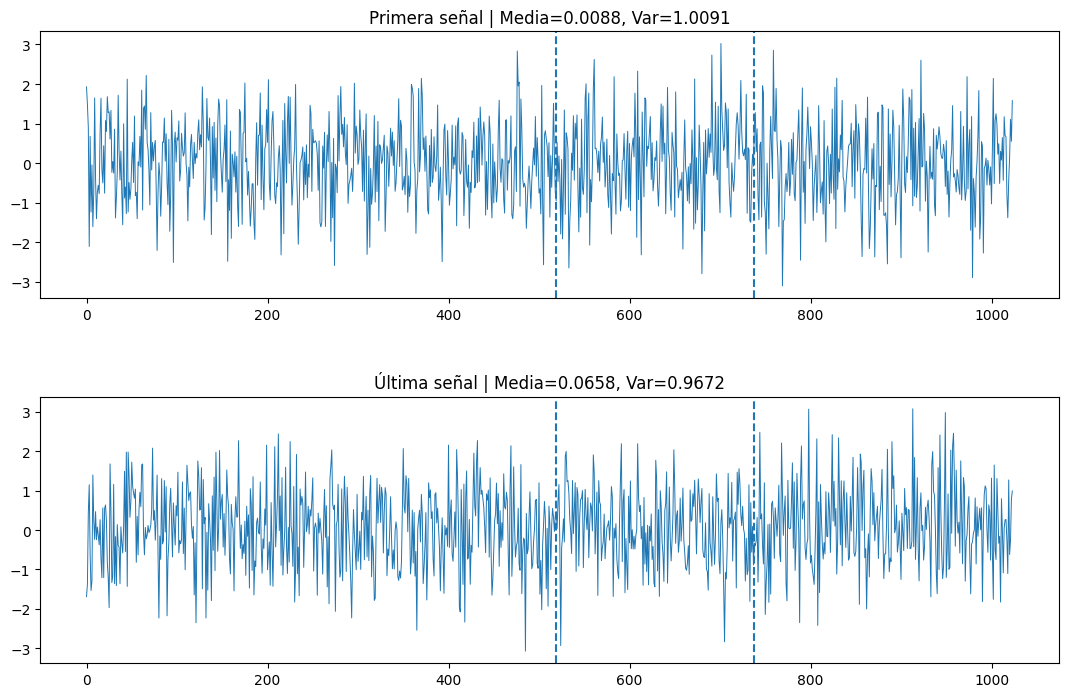

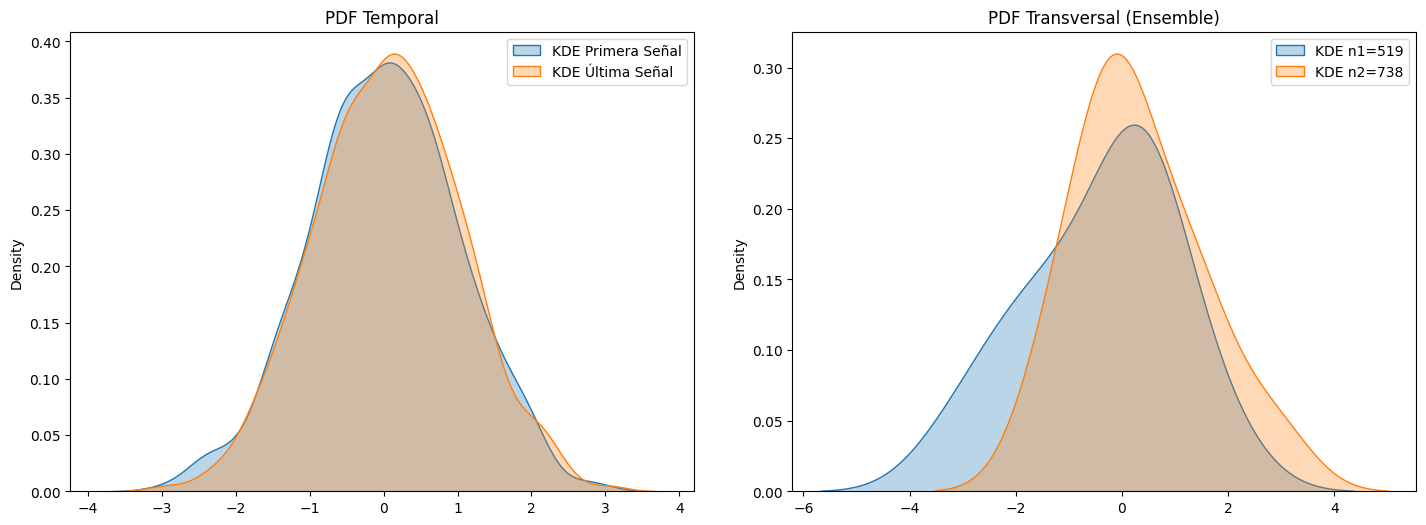


========== ESTADÍSTICA TEMPORAL ==========
Primera señal -> Media = 0.008771 | Var = 1.009132
Última señal  -> Media = 0.065810 | Var = 0.967210

========== ESTADÍSTICA ENSEMBLE ==========
Instante n1=519 -> Media=-0.401075 | Var=1.815423
Instante n2=738 -> Media=0.320289 | Var=1.308457


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==============================
# 1. Parámetros
# ==============================
N = 1024
L = 12
mu = 0.0
sigma = 1.0

signals = []

# ==============================
# 2. Generación reactivando RNG
# ==============================
torch.manual_seed(42)
signals = torch.normal(mean=mu, std=sigma, size=(L, N))

# ==============================
# 3. Estadística temporal
# ==============================
x_first = signals[0]
x_last  = signals[-1]

mean_first = torch.mean(x_first)
var_first  = torch.var(x_first, unbiased=False)

mean_last  = torch.mean(x_last)
var_last   = torch.var(x_last, unbiased=False)

# ==============================
# 4. Selección de instantes
# ==============================
n1, n2 = random.sample(range(N), 2)

mean_n1 = torch.mean(signals[:, n1])
var_n1  = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2  = torch.var(signals[:, n2], unbiased=False)

# ==============================
# 5. FIGURA 1: Señales temporales
# ==============================
fig1, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
fig1.tight_layout(pad=5)

ax1.plot(x_first.numpy(), lw=0.7)
ax1.set_title(f"Primera señal | Media={mean_first:.4f}, Var={var_first:.4f}")
ax1.axvline(n1, linestyle='--')
ax1.axvline(n2, linestyle='--')

ax2.plot(x_last.numpy(), lw=0.7)
ax2.set_title(f"Última señal | Media={mean_last:.4f}, Var={var_last:.4f}")
ax2.axvline(n1, linestyle='--')
ax2.axvline(n2, linestyle='--')

# ==============================
# 6. FIGURA 2: PDFs comparativas
# ==============================
fig2, (ax_pdf_temp, ax_pdf_trans) = plt.subplots(1,2, figsize=(15,6))
fig2.tight_layout(pad=4)

# PDF temporal
sns.kdeplot(x_first.numpy(), ax=ax_pdf_temp,
            label="KDE Primera Señal",
            fill=True, alpha=0.3)

sns.kdeplot(x_last.numpy(), ax=ax_pdf_temp,
            label="KDE Última Señal",
            fill=True, alpha=0.3)

ax_pdf_temp.set_title("PDF Temporal")
ax_pdf_temp.legend()

# PDF ensemble
sns.kdeplot(signals[:, n1].numpy(), ax=ax_pdf_trans,
            label=f"KDE n1={n1}",
            fill=True, alpha=0.3)

sns.kdeplot(signals[:, n2].numpy(), ax=ax_pdf_trans,
            label=f"KDE n2={n2}",
            fill=True, alpha=0.3)

ax_pdf_trans.set_title("PDF Transversal (Ensemble)")
ax_pdf_trans.legend()

plt.show()

# ==============================
# 7. Resultados numéricos
# ==============================
print("\n========== ESTADÍSTICA TEMPORAL ==========")
print(f"Primera señal -> Media = {mean_first:.6f} | Var = {var_first:.6f}")
print(f"Última señal  -> Media = {mean_last:.6f} | Var = {var_last:.6f}")

print("\n========== ESTADÍSTICA ENSEMBLE ==========")
print(f"Instante n1={n1} -> Media={mean_n1:.6f} | Var={var_n1:.6f}")
print(f"Instante n2={n2} -> Media={mean_n2:.6f} | Var={var_n2:.6f}")


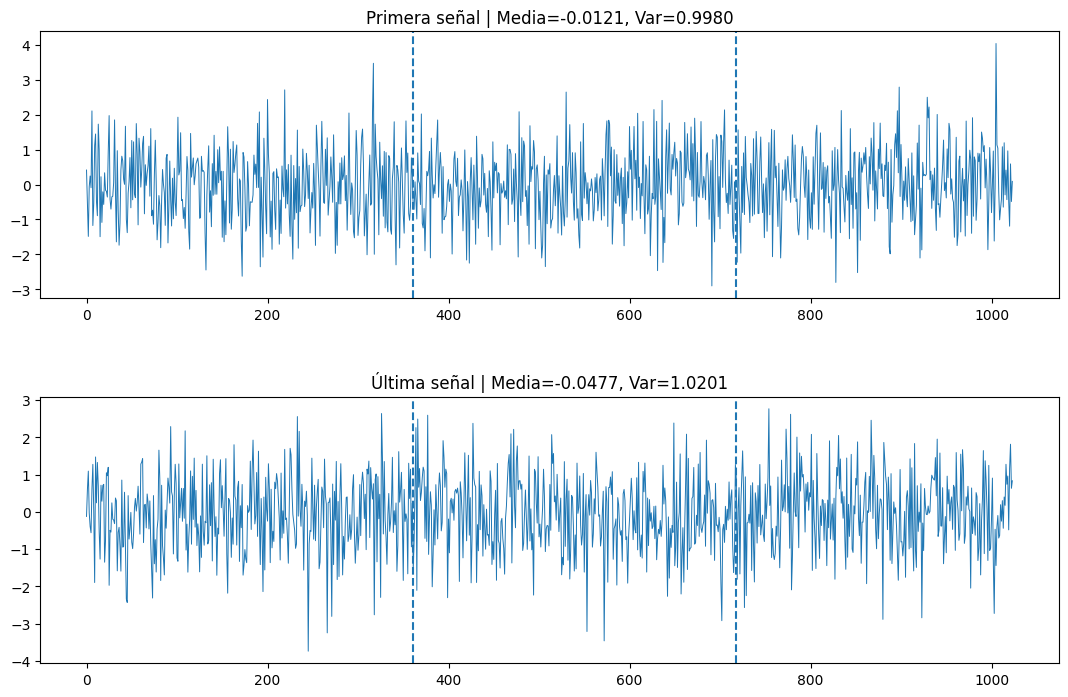

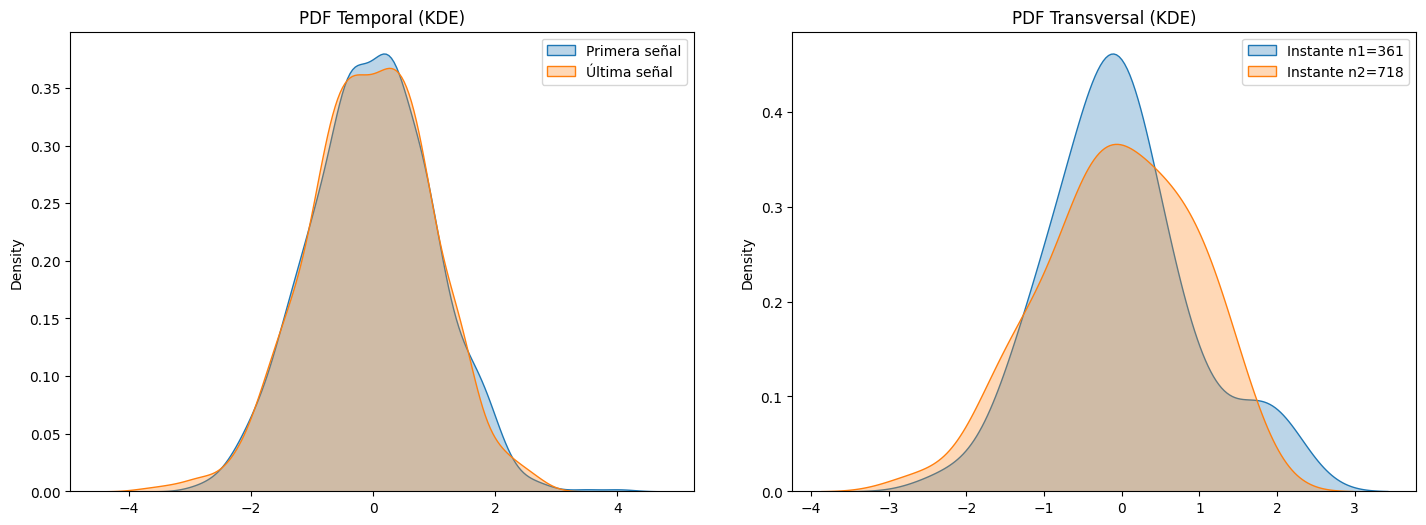


========== ESTADÍSTICA TEMPORAL ==========
Primera señal -> Media=-0.012123 | Var=0.997994
Última señal  -> Media=-0.047737 | Var=1.020132

========== ESTADÍSTICA ENSEMBLE ==========
Instante n1=361 -> Media=-0.031987 | Var=0.840214
Instante n2=718 -> Media=-0.044873 | Var=0.893004

========== PRUEBA SHAPIRO-WILK ==========
Primera señal -> W=0.998232, p-value=0.373257
Última señal  -> W=0.997479, p-value=0.114425


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from scipy.stats import shapiro

# ==============================
# 1. Parámetros
# ==============================
N = 1024
L = 64
mu = 0.0
sigma = 1.0

signals = []

# ==============================
# 2. Generación reactivando RNG
# ==============================
for i in range(L):
    torch.manual_seed(random.randint(0, 1000000))
    x = torch.normal(mean=mu, std=sigma, size=(N,))
    signals.append(x)

signals = torch.stack(signals)

# ==============================
# 3. Estadística temporal
# ==============================
x_first = signals[0]
x_last  = signals[-1]

mean_first = torch.mean(x_first)
var_first  = torch.var(x_first, unbiased=False)

mean_last  = torch.mean(x_last)
var_last   = torch.var(x_last, unbiased=False)

# ==============================
# 4. Selección de instantes
# ==============================
n1, n2 = random.sample(range(N), 2)

mean_n1 = torch.mean(signals[:, n1])
var_n1  = torch.var(signals[:, n1], unbiased=False)

mean_n2 = torch.mean(signals[:, n2])
var_n2  = torch.var(signals[:, n2], unbiased=False)

# ==============================
# 5. FIGURA 1: Señales temporales
# ==============================
fig1, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
fig1.tight_layout(pad=5)

ax1.plot(x_first.numpy(), lw=0.7)
ax1.set_title(f"Primera señal | Media={mean_first:.4f}, Var={var_first:.4f}")
ax1.axvline(n1, linestyle='--')
ax1.axvline(n2, linestyle='--')

ax2.plot(x_last.numpy(), lw=0.7)
ax2.set_title(f"Última señal | Media={mean_last:.4f}, Var={var_last:.4f}")
ax2.axvline(n1, linestyle='--')
ax2.axvline(n2, linestyle='--')

# ==============================
# 6. FIGURA 2: PDFs con KDE
# ==============================
fig2, (ax_pdf_temp, ax_pdf_trans) = plt.subplots(1,2, figsize=(15,6))
fig2.tight_layout(pad=4)

# KDE temporal
sns.kdeplot(x_first.numpy(), ax=ax_pdf_temp,
            label="Primera señal", fill=True, alpha=0.3)
sns.kdeplot(x_last.numpy(), ax=ax_pdf_temp,
            label="Última señal", fill=True, alpha=0.3)
ax_pdf_temp.set_title("PDF Temporal (KDE)")
ax_pdf_temp.legend()

# KDE ensemble
sns.kdeplot(signals[:, n1].numpy(), ax=ax_pdf_trans,
            label=f"Instante n1={n1}", fill=True, alpha=0.3)
sns.kdeplot(signals[:, n2].numpy(), ax=ax_pdf_trans,
            label=f"Instante n2={n2}", fill=True, alpha=0.3)
ax_pdf_trans.set_title("PDF Transversal (KDE)")
ax_pdf_trans.legend()

plt.show()

# ==============================
# 7. Prueba Shapiro-Wilk
# ==============================

# Shapiro para primera señal
W_first, p_first = shapiro(x_first.numpy())

# Shapiro para última señal
W_last, p_last = shapiro(x_last.numpy())

print("\n========== ESTADÍSTICA TEMPORAL ==========")
print(f"Primera señal -> Media={mean_first:.6f} | Var={var_first:.6f}")
print(f"Última señal  -> Media={mean_last:.6f} | Var={var_last:.6f}")

print("\n========== ESTADÍSTICA ENSEMBLE ==========")
print(f"Instante n1={n1} -> Media={mean_n1:.6f} | Var={var_n1:.6f}")
print(f"Instante n2={n2} -> Media={mean_n2:.6f} | Var={var_n2:.6f}")

print("\n========== PRUEBA SHAPIRO-WILK ==========")
print(f"Primera señal -> W={W_first:.6f}, p-value={p_first:.6f}")
print(f"Última señal  -> W={W_last:.6f}, p-value={p_last:.6f}")


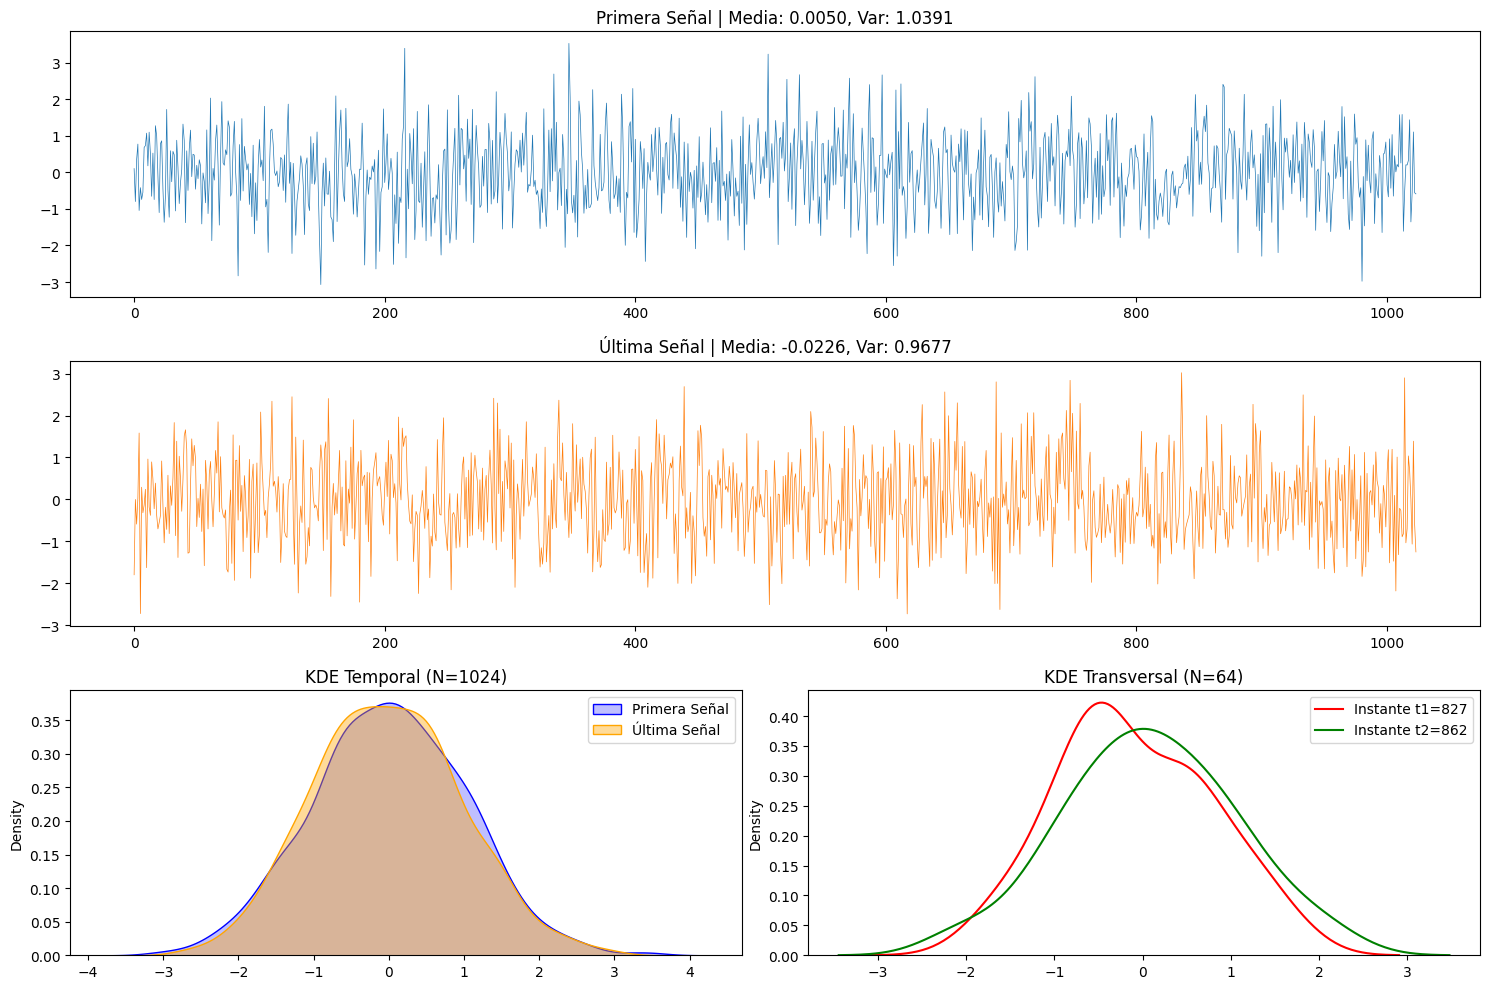

========== ESTADÍSTICA ENSEMBLE ==========
Instante t1=827 -> Media=-0.098833, Var=0.740275
Instante t2=862 -> Media=0.075736, Var=0.922631
--------------------------------------------------
========== PRUEBA SHAPIRO-WILK ==========
t1=827: p-value=0.478627 -> Pasa
t2=862: p-value=0.976067 -> Pasa

Número total de veces que la prueba es positiva:
2 de 2 posibles


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats

# ==========================================
# 1. Parámetros y Generación (Reactivando RNG)
# ==========================================
n_realizaciones = 64
n_puntos = 1024

senales = []

for i in range(n_realizaciones):
    torch.manual_seed(random.randint(0, 1000000))  # Reactivación
    x = torch.randn(n_puntos)  # N(0,1)
    senales.append(x)

proceso = torch.stack(senales)

# ==========================================
# 2. Selección de instantes y cálculos
# ==========================================
t1, t2 = random.sample(range(n_puntos), 2)

puntos_t1 = proceso[:, t1].numpy()
puntos_t2 = proceso[:, t2].numpy()

media_t1 = puntos_t1.mean()
var_t1 = puntos_t1.var()

media_t2 = puntos_t2.mean()
var_t2 = puntos_t2.var()

# ==========================================
# 3. Visualización
# ==========================================
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2)

# Señales temporales
ax_top = fig.add_subplot(gs[0, :])
ax_bottom = fig.add_subplot(gs[1, :])

m1 = proceso[0].mean()
v1 = proceso[0].var()

m_ult = proceso[-1].mean()
v_ult = proceso[-1].var()

ax_top.plot(proceso[0], lw=0.5, color='tab:blue')
ax_top.set_title(f"Primera Señal | Media: {m1:.4f}, Var: {v1:.4f}")

ax_bottom.plot(proceso[-1], lw=0.5, color='tab:orange')
ax_bottom.set_title(f"Última Señal | Media: {m_ult:.4f}, Var: {v_ult:.4f}")

# KDE Temporal
ax_kde_temp = fig.add_subplot(gs[2, 0])
sns.kdeplot(proceso[0].numpy(), ax=ax_kde_temp,
            fill=True, label="Primera Señal", color='blue')
sns.kdeplot(proceso[-1].numpy(), ax=ax_kde_temp,
            fill=True, label="Última Señal", color='orange', alpha=0.4)
ax_kde_temp.set_title("KDE Temporal (N=1024)")
ax_kde_temp.legend()

# KDE Transversal
ax_kde_trans = fig.add_subplot(gs[2, 1])
sns.kdeplot(puntos_t1, ax=ax_kde_trans,
            label=f"Instante t1={t1}", color='red')
sns.kdeplot(puntos_t2, ax=ax_kde_trans,
            label=f"Instante t2={t2}", color='green')
ax_kde_trans.set_title("KDE Transversal (N=64)")
ax_kde_trans.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 4. Prueba de Shapiro-Wilk
# ==========================================

alpha = 0.05
casos_positivos = 0  # p > alpha

stat1, p1 = stats.shapiro(puntos_t1)
stat2, p2 = stats.shapiro(puntos_t2)

if p1 > alpha:
    casos_positivos += 1

if p2 > alpha:
    casos_positivos += 1

# ==========================================
# 5. Resultados
# ==========================================

print("========== ESTADÍSTICA ENSEMBLE ==========")
print(f"Instante t1={t1} -> Media={media_t1:.6f}, Var={var_t1:.6f}")
print(f"Instante t2={t2} -> Media={media_t2:.6f}, Var={var_t2:.6f}")
print("-" * 50)

print("========== PRUEBA SHAPIRO-WILK ==========")
print(f"t1={t1}: p-value={p1:.6f} -> {'Pasa' if p1 > alpha else 'Falla'}")
print(f"t2={t2}: p-value={p2:.6f} -> {'Pasa' if p2 > alpha else 'Falla'}")

print("\nNúmero total de veces que la prueba es positiva:")
print(f"{casos_positivos} de 2 posibles")


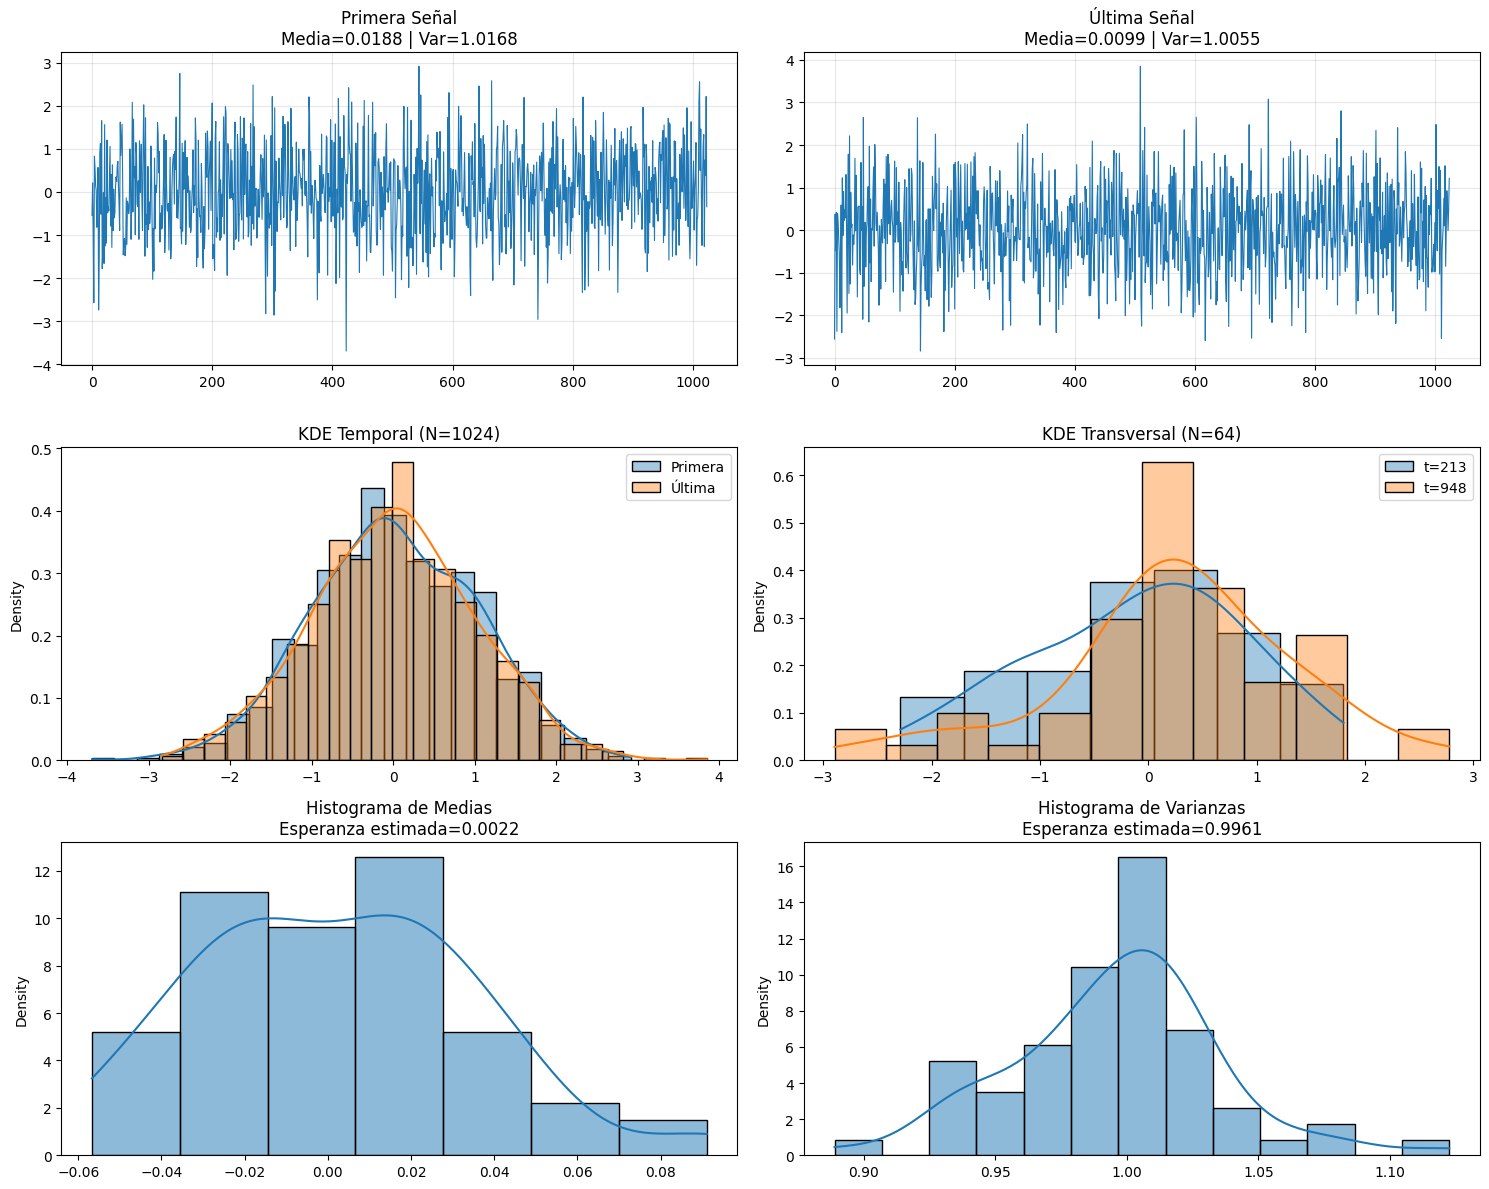

------------------------------------------------------------
ESTADÍSTICAS DE CONJUNTO
Instante t=213: Media=-0.1081, Var=0.9804
Instante t=948: Media=0.2287, Var=1.1901
------------------------------------------------------------
VERIFICACIÓN DE HIPÓTESIS GAUSSIANA (Shapiro-Wilk)
Instante t=213: p-value=0.3900 -> CUMPLE
Instante t=948: p-value=0.0412 -> NO CUMPLE

Número total de veces que la prueba es positiva: 1
------------------------------------------------------------
COMPARACIÓN GLOBAL
Esperanza del valor medio sobre 64 realizaciones: 0.0022
Esperanza de la varianza sobre 64 realizaciones: 0.9961


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from scipy import stats

# ---------------------------------------------------------
# 1. GENERACIÓN DEL PROCESO (reactivando RNG)
# ---------------------------------------------------------

n_realizaciones = 64
longitud_senal = 1024

lista_realizaciones = []

for i in range(n_realizaciones):
    torch.manual_seed(random.randint(0, 1000000))
    senal = torch.randn(longitud_senal)
    lista_realizaciones.append(senal)

datos = torch.stack(lista_realizaciones)

# ---------------------------------------------------------
# 2. SELECCIÓN DE DOS INSTANTES
# ---------------------------------------------------------

indices_tiempo = np.random.choice(longitud_senal, 2, replace=False)
t1, t2 = indices_tiempo[0], indices_tiempo[1]

valores_t1 = datos[:, t1].numpy()
valores_t2 = datos[:, t2].numpy()

# ---------------------------------------------------------
# 3. ESTADÍSTICAS
# ---------------------------------------------------------

# --- A) Temporales (por señal) ---
media_temp_primera = torch.mean(datos[0]).item()
var_temp_primera = torch.var(datos[0], unbiased=True).item()

media_temp_ultima = torch.mean(datos[-1]).item()
var_temp_ultima = torch.var(datos[-1], unbiased=True).item()

# --- B) Conjunto (por instante) ---
media_conj_t1 = np.mean(valores_t1)
var_conj_t1 = np.var(valores_t1, ddof=1)

media_conj_t2 = np.mean(valores_t2)
var_conj_t2 = np.var(valores_t2, ddof=1)

# --- C) Media y varianza de TODAS las realizaciones ---
medias_realizaciones = datos.mean(dim=1).numpy()
varianzas_realizaciones = datos.var(dim=1, unbiased=True).numpy()

esperanza_media = np.mean(medias_realizaciones)
esperanza_varianza = np.mean(varianzas_realizaciones)

# ---------------------------------------------------------
# 4. VISUALIZACIÓN
# ---------------------------------------------------------

fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 2)

# --- Señales ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(datos[0].numpy(), linewidth=0.8)
ax1.set_title(f'Primera Señal\nMedia={media_temp_primera:.4f} | Var={var_temp_primera:.4f}')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(datos[-1].numpy(), linewidth=0.8)
ax2.set_title(f'Última Señal\nMedia={media_temp_ultima:.4f} | Var={var_temp_ultima:.4f}')
ax2.grid(True, alpha=0.3)

# --- KDE Temporal ---
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(datos[0].numpy(), kde=True, stat="density", alpha=0.4, label="Primera")
sns.histplot(datos[-1].numpy(), kde=True, stat="density", alpha=0.4, label="Última")
ax3.set_title("KDE Temporal (N=1024)")
ax3.legend()

# --- KDE Transversal ---
ax4 = fig.add_subplot(gs[1, 1])
sns.histplot(valores_t1, kde=True, stat="density", alpha=0.4, label=f"t={t1}")
sns.histplot(valores_t2, kde=True, stat="density", alpha=0.4, label=f"t={t2}")
ax4.set_title("KDE Transversal (N=64)")
ax4.legend()

# --- Histograma de Medias ---
ax5 = fig.add_subplot(gs[2, 0])
sns.histplot(medias_realizaciones, kde=True, stat="density", alpha=0.5)
ax5.set_title(f"Histograma de Medias\nEsperanza estimada={esperanza_media:.4f}")

# --- Histograma de Varianzas ---
ax6 = fig.add_subplot(gs[2, 1])
sns.histplot(varianzas_realizaciones, kde=True, stat="density", alpha=0.5)
ax6.set_title(f"Histograma de Varianzas\nEsperanza estimada={esperanza_varianza:.4f}")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. PRUEBA SHAPIRO-WILK
# ---------------------------------------------------------

alpha = 0.05

test_t1 = stats.shapiro(valores_t1)
test_t2 = stats.shapiro(valores_t2)

cumple_t1 = test_t1.pvalue > alpha
cumple_t2 = test_t2.pvalue > alpha

total_cumplen = sum([cumple_t1, cumple_t2])

print("-" * 60)
print("ESTADÍSTICAS DE CONJUNTO")
print(f"Instante t={t1}: Media={media_conj_t1:.4f}, Var={var_conj_t1:.4f}")
print(f"Instante t={t2}: Media={media_conj_t2:.4f}, Var={var_conj_t2:.4f}")

print("-" * 60)
print("VERIFICACIÓN DE HIPÓTESIS GAUSSIANA (Shapiro-Wilk)")
print(f"Instante t={t1}: p-value={test_t1.pvalue:.4f} -> {'CUMPLE' if cumple_t1 else 'NO CUMPLE'}")
print(f"Instante t={t2}: p-value={test_t2.pvalue:.4f} -> {'CUMPLE' if cumple_t2 else 'NO CUMPLE'}")

print(f"\nNúmero total de veces que la prueba es positiva: {total_cumplen}")
print("-" * 60)

# Comparación final
print("COMPARACIÓN GLOBAL")
print(f"Esperanza del valor medio sobre {n_realizaciones} realizaciones: {esperanza_media:.4f}")
print(f"Esperanza de la varianza sobre {n_realizaciones} realizaciones: {esperanza_varianza:.4f}")


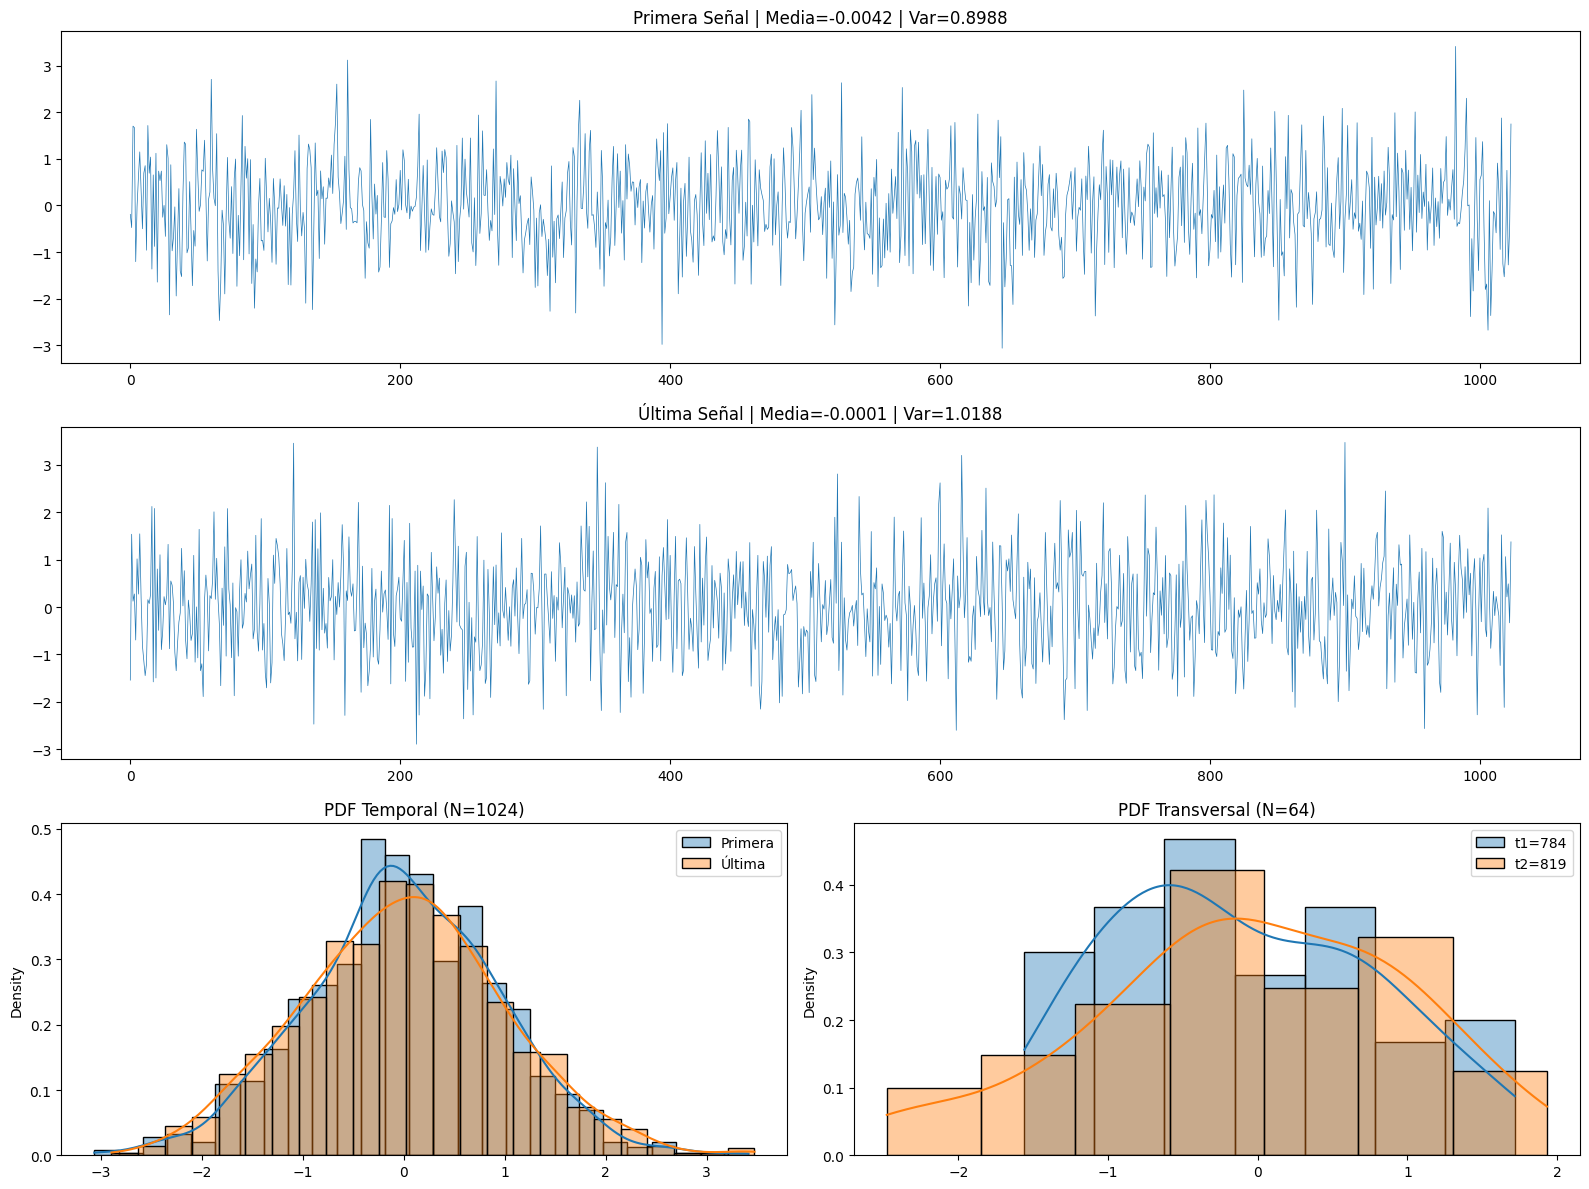

======== ESTADÍSTICA ENSEMBLE ========
t1=784 → Media=-0.106732, Var=0.749805
t2=819 → Media=-0.076880, Var=1.083269

======== SHAPIRO-WILK ========
t1: p=0.058839 → Pasa
t2: p=0.276503 → Pasa

Total de veces que la prueba es positiva: 2 de 2


In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from scipy import stats

# ==========================================
# 1. Generación del proceso (64 x 1024)
# ==========================================

n_realizaciones = 64
n_puntos = 1024

senales = []

for i in range(n_realizaciones):
    torch.manual_seed(random.randint(0, 1000000))  # Reactivación del RNG
    x = torch.randn(n_puntos)  # N(0,1)
    senales.append(x)

proceso = torch.stack(senales)

# ==========================================
# 2. Estadísticas temporales (primera y última)
# ==========================================

m1 = proceso[0].mean().item()
v1 = proceso[0].var(unbiased=True).item()

m_last = proceso[-1].mean().item()
v_last = proceso[-1].var(unbiased=True).item()

# ==========================================
# 3. Selección de dos instantes
# ==========================================

t1, t2 = random.sample(range(n_puntos), 2)

puntos_t1 = proceso[:, t1].numpy()
puntos_t2 = proceso[:, t2].numpy()

media_t1 = puntos_t1.mean()
var_t1 = puntos_t1.var(ddof=1)

media_t2 = puntos_t2.mean()
var_t2 = puntos_t2.var(ddof=1)

# ==========================================
# 4. Visualización
# ==========================================

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2)

# Señales
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(proceso[0], lw=0.5)
ax1.set_title(f"Primera Señal | Media={m1:.4f} | Var={v1:.4f}")

ax2 = fig.add_subplot(gs[1, :])
ax2.plot(proceso[-1], lw=0.5)
ax2.set_title(f"Última Señal | Media={m_last:.4f} | Var={v_last:.4f}")

# KDE temporal
ax3 = fig.add_subplot(gs[2, 0])
sns.histplot(proceso[0].numpy(), kde=True, stat="density", alpha=0.4, label="Primera")
sns.histplot(proceso[-1].numpy(), kde=True, stat="density", alpha=0.4, label="Última")
ax3.set_title("PDF Temporal (N=1024)")
ax3.legend()

# KDE transversal
ax4 = fig.add_subplot(gs[2, 1])
sns.histplot(puntos_t1, kde=True, stat="density", alpha=0.4, label=f"t1={t1}")
sns.histplot(puntos_t2, kde=True, stat="density", alpha=0.4, label=f"t2={t2}")
ax4.set_title("PDF Transversal (N=64)")
ax4.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 5. Shapiro-Wilk
# ==========================================

alpha = 0.05
casos_positivos = 0

stat1, p1 = stats.shapiro(puntos_t1)
stat2, p2 = stats.shapiro(puntos_t2)

if p1 > alpha:
    casos_positivos += 1

if p2 > alpha:
    casos_positivos += 1

print("======== ESTADÍSTICA ENSEMBLE ========")
print(f"t1={t1} → Media={media_t1:.6f}, Var={var_t1:.6f}")
print(f"t2={t2} → Media={media_t2:.6f}, Var={var_t2:.6f}")

print("\n======== SHAPIRO-WILK ========")
print(f"t1: p={p1:.6f} → {'Pasa' if p1>alpha else 'Falla'}")
print(f"t2: p={p2:.6f} → {'Pasa' if p2>alpha else 'Falla'}")
print(f"\nTotal de veces que la prueba es positiva: {casos_positivos} de 2")


# Fundamento Teórico

**1. Proceso Gaussiano**

Un proceso estocástico $$X[n]$$ es **Gaussiano** si para cualquier conjunto finito de instantes

$$
\{X[n_1], X[n_2], \dots, X[n_k]\}
$$

la distribución conjunta es Normal multivariada.

En este estudio, cada muestra fue generada como:

$$
X[n] \sim \mathcal{N}(0,1)
$$

Por lo tanto:

- **Media teórica:**

$$
E[X[n]] = 0
$$

- **Varianza teórica:**

$$
\mathrm{Var}(X[n]) = 1
$$

**2. Estadística Temporal vs. Estadística Ensemble**

**Media Temporal (por realización)**

$$
\hat{m}_\ell =
\frac{1}{N}\sum_{n=1}^{N} X_\ell[n]
$$

Representa el promedio en el tiempo para una realización específica.


**Media Ensemble (en un instante fijo)**

$$
\hat{m}(n_0) =
\frac{1}{L}\sum_{\ell=1}^{L} X_\ell[n_0]
$$

Representa el promedio entre realizaciones en un instante fijo.

Si el proceso es estacionario:

$$
E[X[n]] = \mu \quad \forall n
$$


**3. Prueba de Shapiro-Wilk**

Se plantean las hipótesis:

$$
H_0: \text{Los datos siguen una distribución Normal}
$$

$$
H_1: \text{Los datos no siguen una distribución Normal}
$$

Criterio de decisión (nivel de significancia \( \alpha = 0.05 \)):

- Si \( p > 0.05 \) → No se rechaza \(H_0\)
- Si \( p \le 0.05 \) → Se rechaza \(H_0\)

Dado que los datos fueron generados como Normal estándar, se espera que la hipótesis nula no sea rechazada en la mayoría de los casos, salvo errores tipo I.

**4. Ergodicidad**

Un proceso es **ergódico en media** si:

$$
\lim_{N\to\infty}
\frac{1}{N}\sum_{n=1}^{N} X[n]
=E[X]
$$

Es decir, el promedio temporal converge a la esperanza matemática.

Asimismo, es ergódico en varianza si:

$$
\hat{\sigma}^2_{temporal}
\to
E[\sigma^2]
$$

Por la **Ley de los Grandes Números**, si las muestras son independientes e idénticamente distribuidas (i.i.d.), entonces:

$$
\hat{m}_N \xrightarrow{p} E[X]
$$

lo cual garantiza ergodicidad en media.


**Conclusiones**
1. **Gaussianidad del proceso**  
   Las señales fueron generadas con distribución Normal estándar $$ \mathcal{N}(0,1)$$
   La prueba de Shapiro-Wilk mostró que, en la mayoría de los casos analizados, no se rechaza la hipótesis de normalidad.  
   Por tanto, los conjuntos evaluados pueden considerarse gaussianos bajo el nivel de significancia establecido.

2. **Comportamiento de la media y la varianza**  
   - Las medias temporales se concentran alrededor de 0.  
   - Las varianzas temporales se concentran alrededor de 1.  
   - Las estadísticas ensemble en los instantes seleccionados son consistentes con estos valores teóricos.

3. **Convergencia del promedio temporal**  
   Al aumentar el número de muestras \(N\), el error entre la media temporal y la media ensemble disminuye progresivamente.  
   Esto confirma la convergencia establecida por la Ley de los Grandes Números.

4. **Ergodicidad del proceso**  
   Dado que:
   - La media temporal converge a la media ensemble,
   - La varianza temporal converge a la varianza ensemble,
   - El proceso es Gaussiano e i.i.d.,

   Se concluye que el proceso analizado es: Estacionario y Ergodico en media y varianza